## Problem Statement

### Business context

Employee Promotion means the ascension of an employee to higher ranks, this aspect of the job is what drives employees the most. The ultimate reward for dedication and loyalty towards an organization and the HR team plays an important role in handling all these promotion tasks based on ratings and other attributes available.

The HR team in JMD company stored data on the promotion cycle last year, which consists of details of all the employees in the company working last year and also if they got promoted or not, but every time this process gets delayed due to so many details available for each employee - it gets difficult to compare and decide.


### Objective

For the upcoming appraisal cycle, the HR team wants to utilize the stored data and leverage machine learning to make a model that will predict if a person is eligible for promotion or not. You, as a data scientist at JMD company, need to come up with the best possible model that will help the HR team to predict if a person is eligible for promotion or not.


### Data Description

- employee_id: Unique ID for the employee
- department: Department of employee
- region: Region of employment (unordered)
- education: Education Level
- gender: Gender of Employee
- recruitment_channel: Channel of recruitment for employee
- no_ of_ trainings: no of other training completed in the previous year on soft skills, technical skills, etc.
- age: Age of Employee
- previous_ year_ rating: Employee Rating for the previous year
- length_ of_ service: Length of service in years
- awards_ won: if awards won during the previous year then 1 else 0
- avg_ training_ score: Average score in current training evaluations
- is_promoted: (Target) Recommended for promotion

## Importing necessary libraries

In [73]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To handle missing values
from sklearn.impute import SimpleImputer

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset

In [5]:
url="/content/drive/MyDrive/Python Files/employee_promotion.csv"
employees=pd.read_csv(url)

In [6]:
employees.shape

(54808, 13)

## Data Overview

In [7]:
data=employees.copy()

In [8]:
# let's view the first 5 rows of the data
data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [9]:
# let's view the last 5 rows of the data
data.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78.0,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56.0,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79.0,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,NaN,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49.0,0


In [10]:
# let's check the data types of the columns in the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.4+ MB


*   There are a total of 13 columns and 54808 observations in the dataset
*   We can see that 3 columns have less than 54808 non-null values i.e. columns have missing values.







In [11]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

There is no duplicate values in this dataset.

In [12]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
employee_id,0.00
department,0.00
region,0.00
education,4.40
gender,0.00
recruitment_channel,0.00
no_of_trainings,0.00
age,0.00
previous_year_rating,7.52
length_of_service,0.00




*   Education column has 4.40% missing values out of the total observations.
*   Previous_year_rating column has	7.52% missing values out of the total observations.
*   Avg_training_score column has 4.67% missing values out of the total observations.
*   We will impute these values after splitting the data into train,validation and test sets.







In [13]:
# Checking for the null value in the dataset
data.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


#####**Let's check the number of unique values in each column**

In [14]:
data.nunique()

,0
employee_id,54808
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,10
age,41
previous_year_rating,5
length_of_service,35


In [15]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,54808.0,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.00,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.00,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.00,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.00,5.0,7.0,37.0
awards_won,54808.0,0.023172,0.150450,0.0,0.00,0.0,0.0,1.0
avg_training_score,52248.0,63.712238,13.521910,39.0,51.00,60.0,77.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.00,0.0,0.0,1.0




*  The minimum number of training provided for the employees is 1 and maximum is 10.
*   The employees age is from 20 to 60 and the mean age is 34.8.This shows that This shows that majority of the customers are under 35 years of age.
*   50% of the employees has a rating of 3
*   75% of the employees does not won any awards.





#####Dropping all the employee Id values

In [16]:
data.drop('employee_id',axis=1,inplace=True)

####Checking the value count for each category of categorical variables

In [17]:
cat_cols=list(data.select_dtypes(include='object').columns)
for col in cat_cols:
  print(data[col].value_counts())
  print("-" * 50)

department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64
--------------------------------------------------
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dty



*   We have more employees in region 2 and 22
*   Most of the employees have either Bachelors or Masters Degree.
*   Male employees are more compared to female employees.
*   Employees through referral are very less compared to sourcing and other.







## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. How is the distribution of average training score of  employee ?
2. How is the distribution age of  employee ?
3. How does the change in length of service (`length_of_service`) vary by the employee's promotion status (`is_promoted`)?
4. How does the previous rating(`previous_year_rating`) vary by the employee's promotion status (`is_promoted`)?
5. What are the attributes that have a strong correlation with each other?



#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [18]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [19]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [20]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [42]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

###Univariate Analysis

####Observation on Department

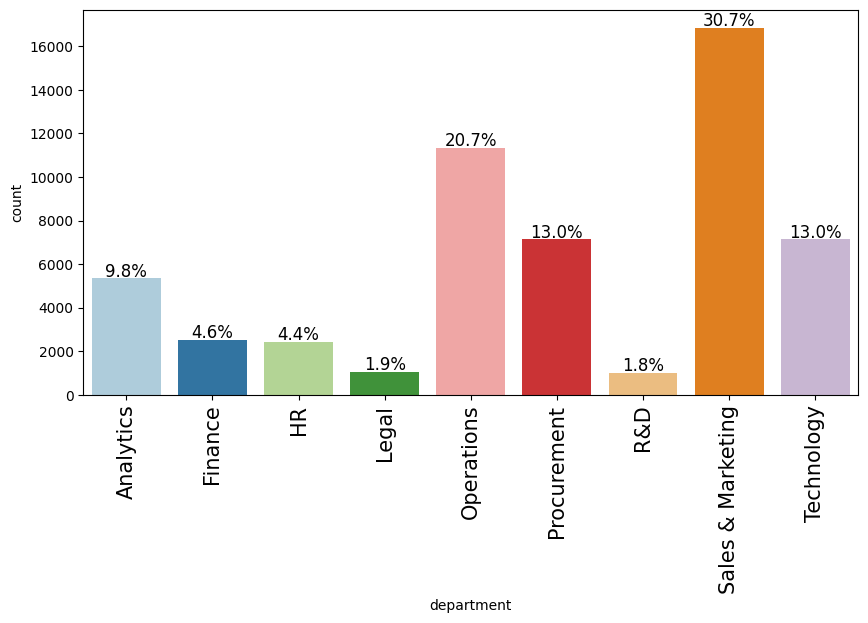

In [21]:
labeled_barplot(data,'department',perc=True)

Majority of the employees are in Sales&Marketing or Operations.
Least employees are in R&D or legal.

####Observation on Region

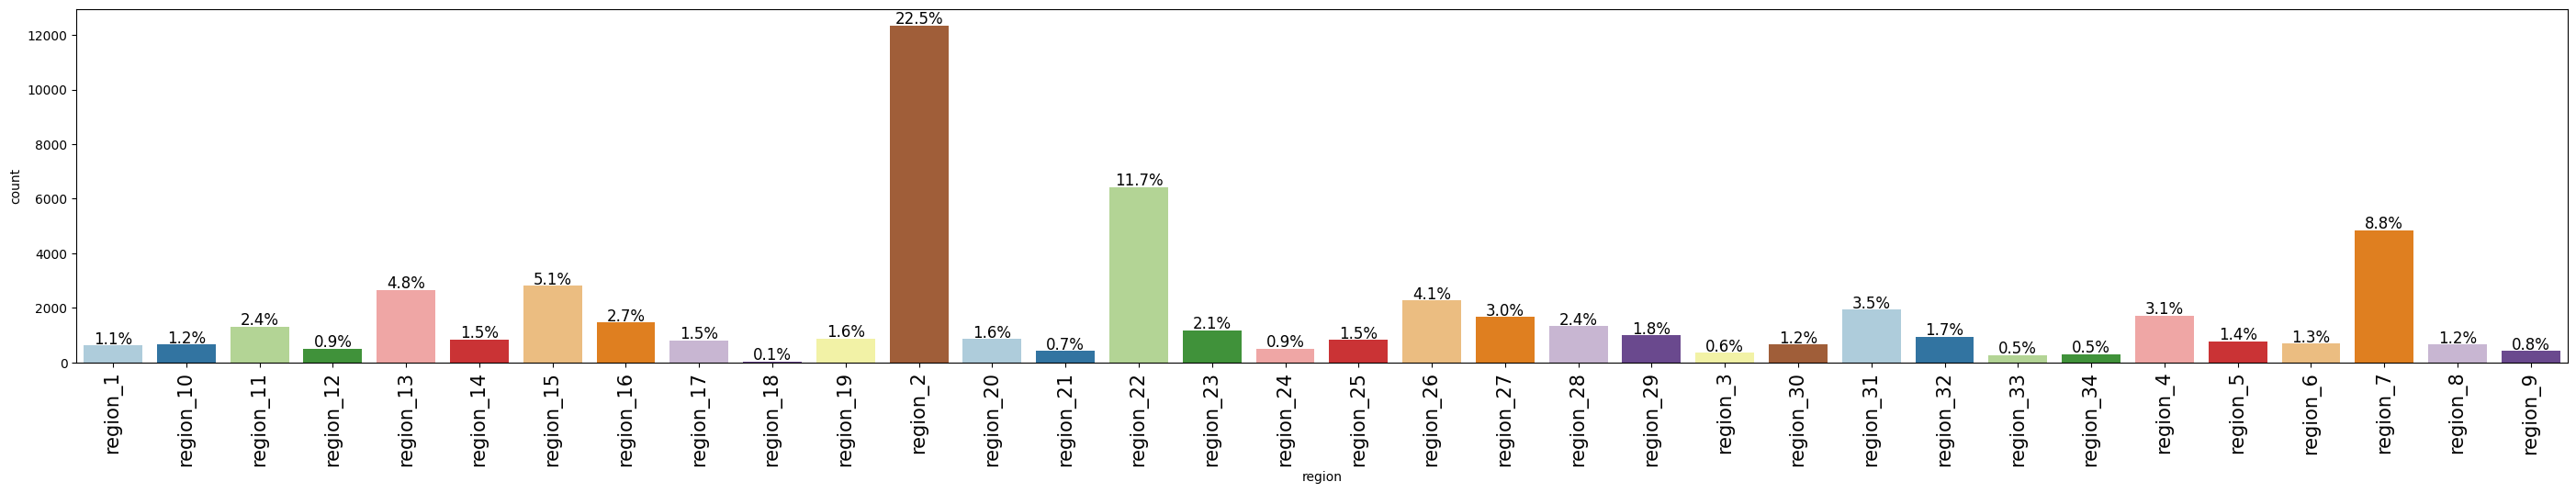

In [22]:
labeled_barplot(data,'region',perc=True)

Majority of the employees are in Region_2,region_22 or region_7.

####Observation on Education

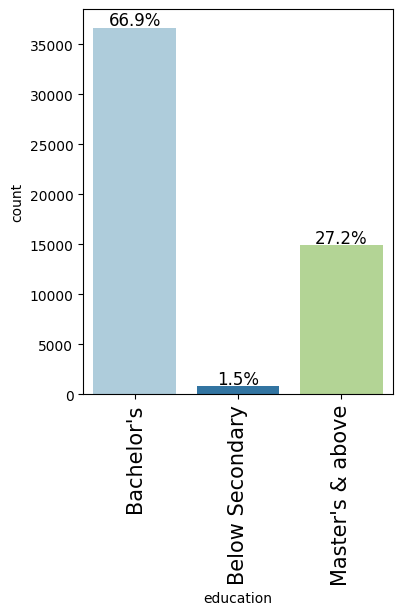

In [24]:
labeled_barplot(data,'education',perc=True)

Almost 94% of employees having a Bachelors or Masters and above while 1.5% employees are having below secondary level.

####Observation on Gender

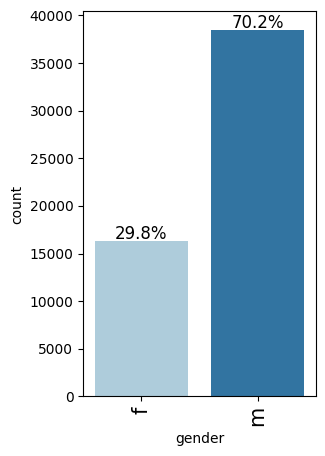

In [25]:
labeled_barplot(data,'gender',perc=True)

Company is having 70.2% male employees and 29.8% of female employees.

####Observation on recruitment_channel

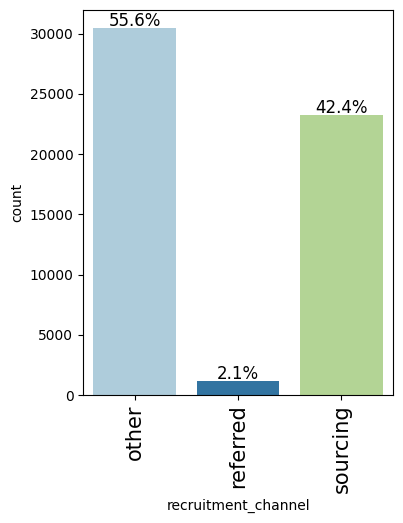

In [26]:
labeled_barplot(data,'recruitment_channel',perc=True)

Company hired majority of employees through sourcing or other methods.

####Observation on Number of trainings

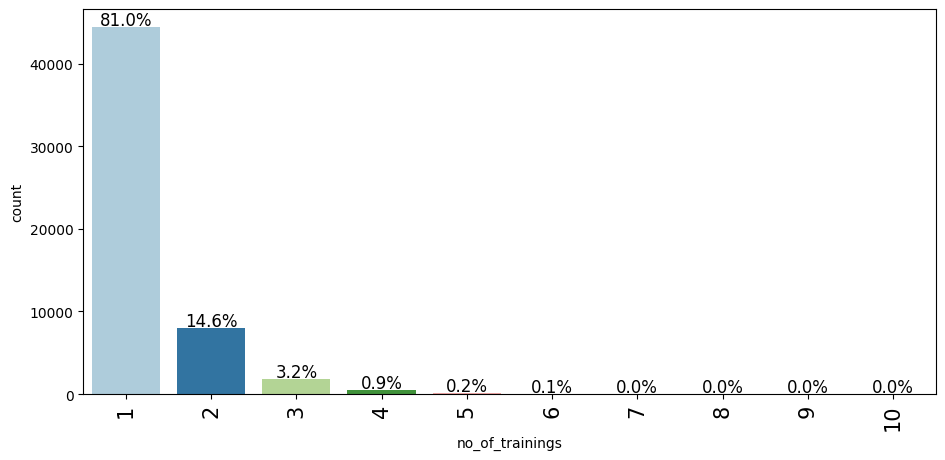

In [27]:
labeled_barplot(data,'no_of_trainings',perc=True)

The majority of employees has got only 1-2 trainings indicating highly skewed distribution.Very few employees undergo more than 3 trainings.

####Observation on Age

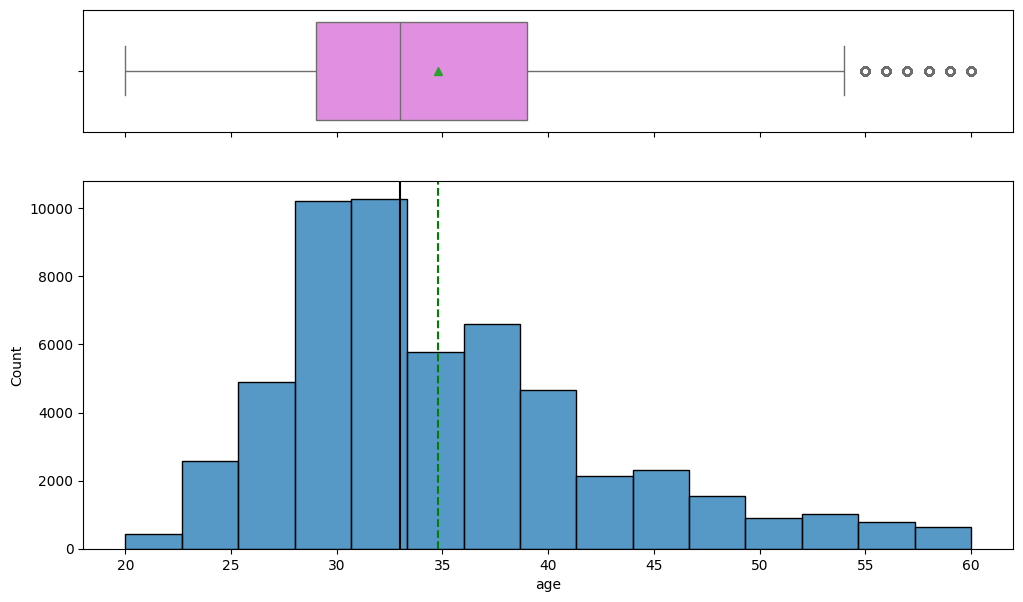

In [28]:
histogram_boxplot(data,'age',bins=15)

Most customers fall below the age 35,with a significant concentration between 28 and 38 years.

####Observation on previous year rating

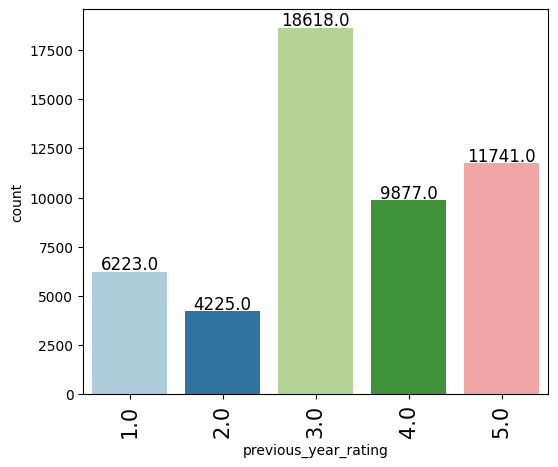

In [29]:
labeled_barplot(data,'previous_year_rating')

The majority of employees got 3 or above ratings

####Observation on length of service

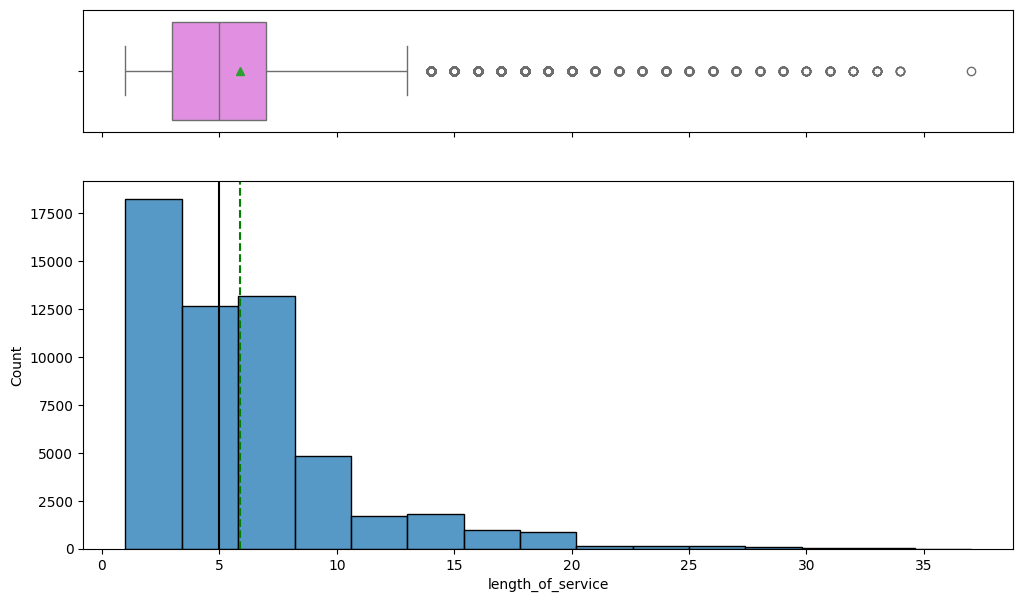

In [30]:
histogram_boxplot(data,'length_of_service',bins=15)

The distribution of length of service is highly right skewed,with most employees having a tenure between 1and 6 years.A small number of employees have significantly higher tenure,creating multiple outliers on the higher end.



####Observation on Awards won

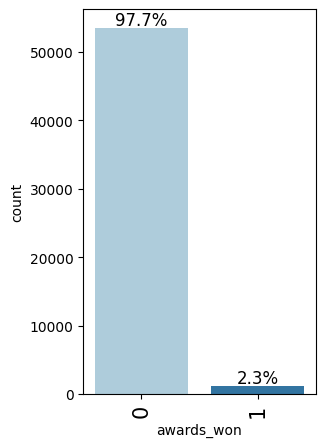

In [31]:
labeled_barplot(data,'awards_won',perc=True)

Only a very few employees won awards.97.7% of employees doesnt get any awards

####Observation on Average training score

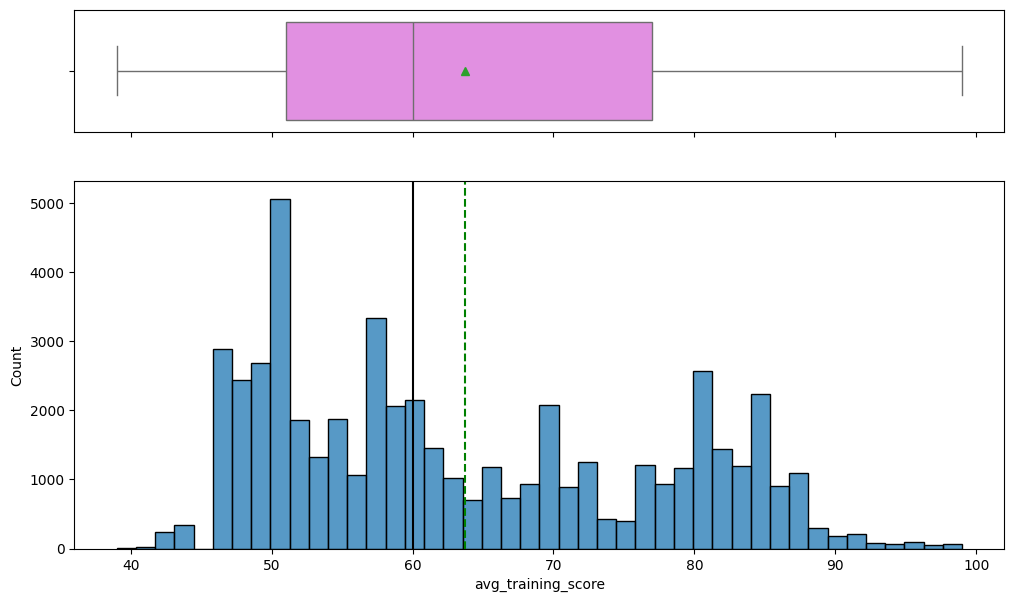

In [32]:
histogram_boxplot(data,'avg_training_score')

The average training score shows a wide distribution,with most employees scoring between 50 and 80.Its slightly right skewed distribution.

####Observation on promotion

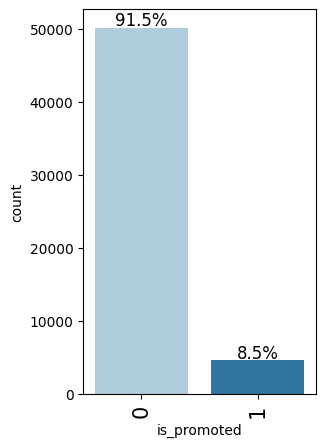

In [33]:
labeled_barplot(data,'is_promoted',perc=True)

The dataset is highly imbalanced,with approximately 91.5% of employees not got promotion recommendation and only 8.5% got promoted

###Bivariate Analysis

####Department vs Target

is_promoted            0     1    All
department                           
All                50140  4668  54808
Sales & Marketing  15627  1213  16840
Operations         10325  1023  11348
Technology          6370   768   7138
Procurement         6450   688   7138
Analytics           4840   512   5352
Finance             2330   206   2536
HR                  2282   136   2418
R&D                  930    69    999
Legal                986    53   1039
------------------------------------------------------------------------------------------------------------------------


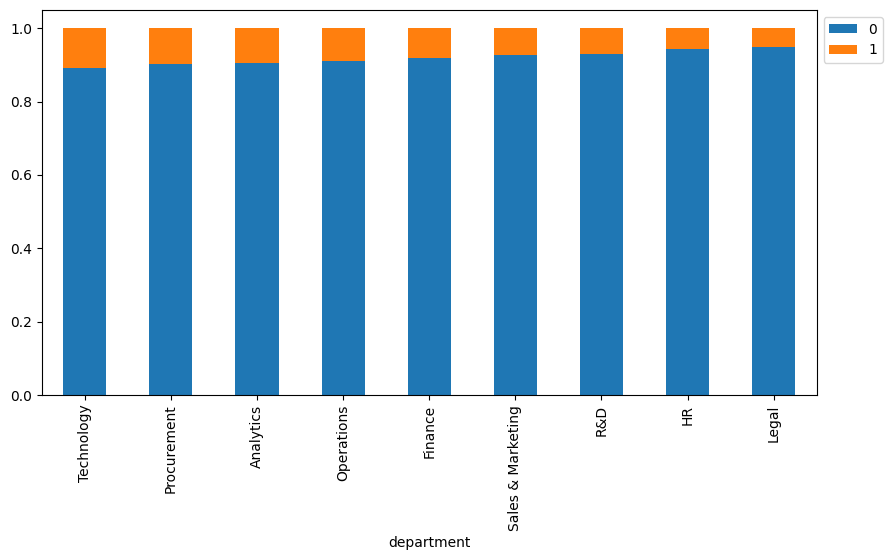

In [34]:
stacked_barplot(data,'department','is_promoted')  #department vs target

Promotion rates are relatively consistent across departments,with only slight variations.No single department shows a significantly higher promotion rate compared to others.

####Region vs Target

is_promoted      0     1    All
region                         
All          50140  4668  54808
region_2     11354   989  12343
region_22     5694   734   6428
region_7      4327   516   4843
region_4      1457   246   1703
region_13     2418   230   2648
region_15     2586   222   2808
region_28     1164   154   1318
region_26     2117   143   2260
region_23     1038   137   1175
region_27     1528   131   1659
region_31     1825   110   1935
region_17      687   109    796
region_25      716   103    819
region_16     1363   102   1465
region_11     1241    74   1315
region_14      765    62    827
region_30      598    59    657
region_1       552    58    610
region_8       602    53    655
region_19      821    53    874
region_10      597    51    648
region_20      801    49    850
region_29      951    43    994
region_32      905    40    945
region_3       309    37    346
region_5       731    35    766
region_12      467    33    500
region_6       658    32    690
region_2

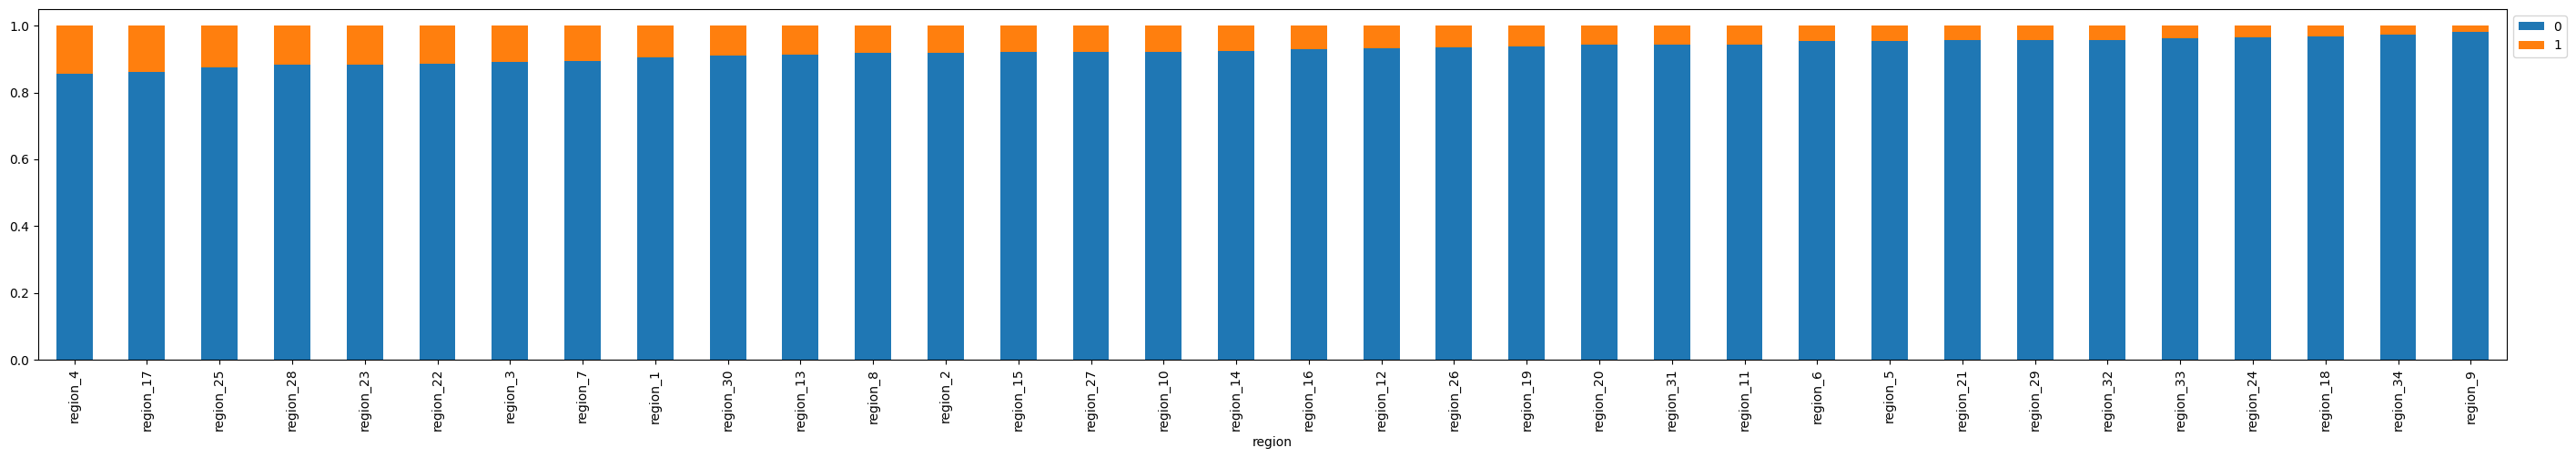

In [35]:
stacked_barplot(data,'region','is_promoted')  #region vs target

Promotion rates vary slightly across regions,but the overall differences are not substantial.It indicates that no strong regional influence on promotion.

####Education vs Target

is_promoted           0     1    All
education                           
All               47853  4546  52399
Bachelor's        33661  3008  36669
Master's & above  13454  1471  14925
Below Secondary     738    67    805
------------------------------------------------------------------------------------------------------------------------


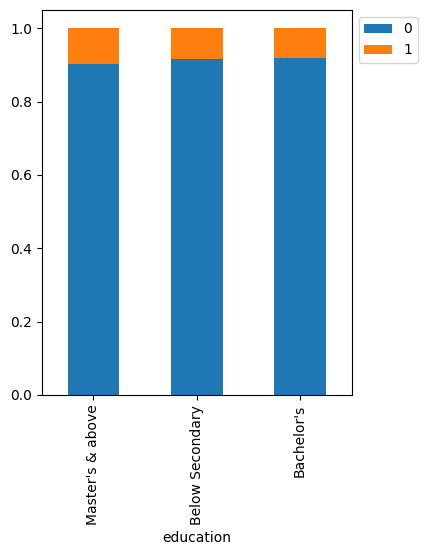

In [36]:
stacked_barplot(data,'education','is_promoted')  #education vs target

Employees with Masters and above show a marginally higher promotion rate compared to others.But promotion rates are fairly similar across all education levels.

####Gender Vs Target

is_promoted      0     1    All
gender                         
All          50140  4668  54808
m            35295  3201  38496
f            14845  1467  16312
------------------------------------------------------------------------------------------------------------------------


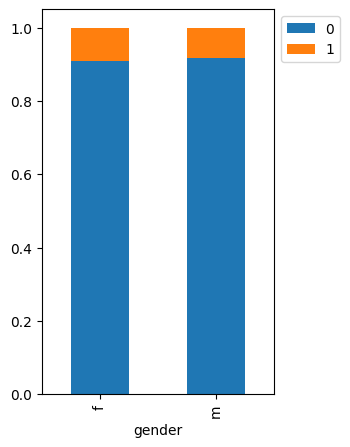

In [37]:
stacked_barplot(data,'gender','is_promoted')  #gender vs target

Gender doesnt have any  impact  on promotion

####Recruitment_channel vs Promotion

is_promoted              0     1    All
recruitment_channel                    
All                  50140  4668  54808
other                27890  2556  30446
sourcing             21246  1974  23220
referred              1004   138   1142
------------------------------------------------------------------------------------------------------------------------


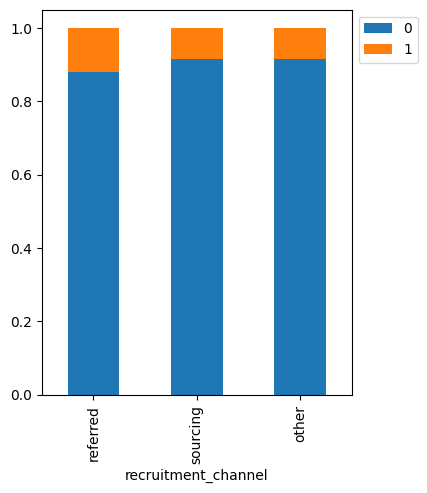

In [38]:
stacked_barplot(data,'recruitment_channel','is_promoted')

The employees who are hired through referral have more promotion rates compared to sourcing and other.

####Number of training vs Target

is_promoted          0     1    All
no_of_trainings                    
All              50140  4668  54808
1                40468  3910  44378
2                 7382   605   7987
3                 1654   122   1776
4                  442    26    468
5                  125     3    128
6                   42     2     44
7                   12     0     12
8                    5     0      5
9                    5     0      5
10                   5     0      5
------------------------------------------------------------------------------------------------------------------------


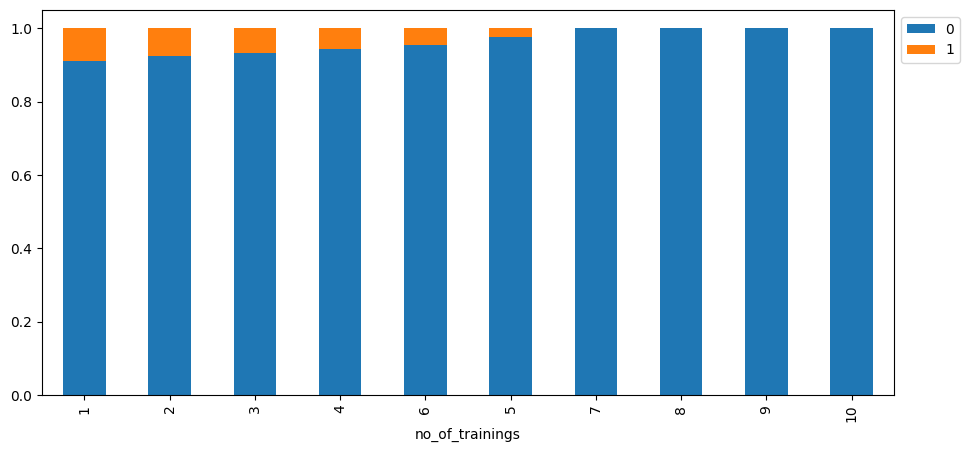

In [39]:
stacked_barplot(data,'no_of_trainings','is_promoted')

Employees with fewer trainings(1-3) have relatively higher promotion rates,while promotion likelihood decreases as the number of trainings increases.

####Age vs Target

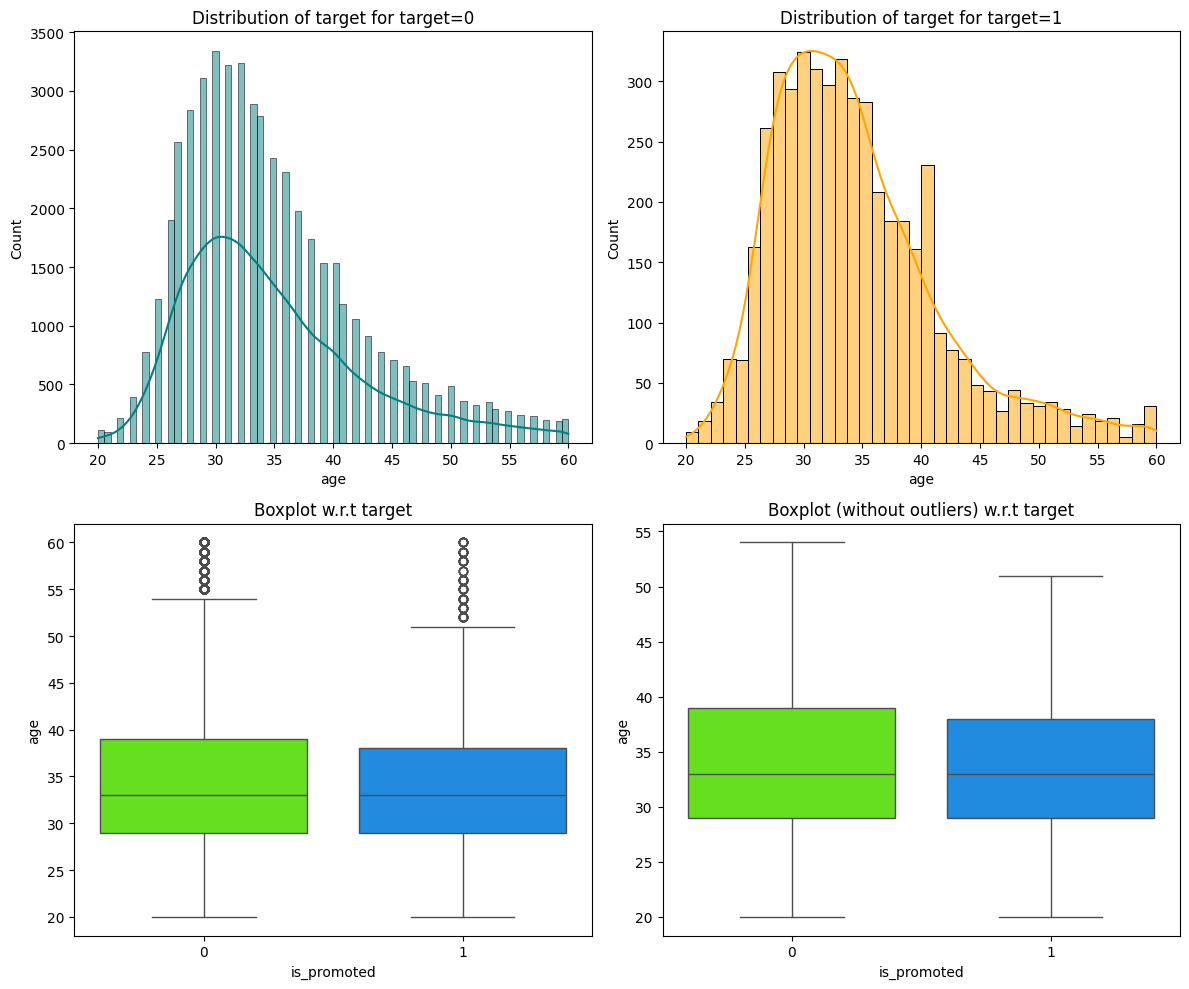

In [43]:
distribution_plot_wrt_target(data,'age','is_promoted')

The age distribution of promoted and non-promoted employees is very similar,with most employees in both groups falling between 28 and 38 years.There is no significant difference in age between the two groups.

####Previous_year_rating vs Target

is_promoted               0     1    All
previous_year_rating                    
All                   46355  4329  50684
5.0                    9820  1921  11741
3.0                   17263  1355  18618
4.0                    9093   784   9877
2.0                    4044   181   4225
1.0                    6135    88   6223
------------------------------------------------------------------------------------------------------------------------


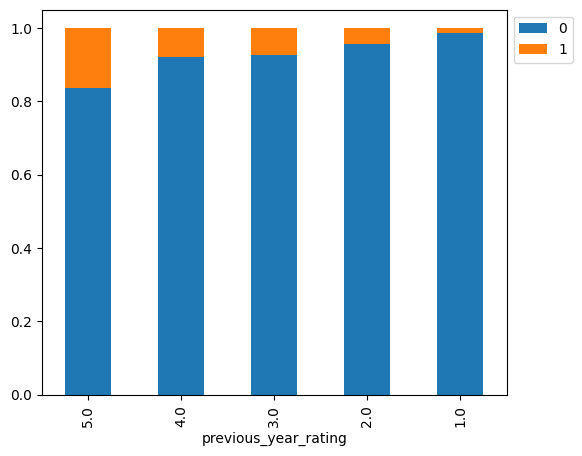

In [44]:
stacked_barplot(data,'previous_year_rating','is_promoted')

Employees with higher previous year ratings have a significantly higher chance of being promoted.Promotion rate increases steadily from rating 1 to rating 5.

####Length_of_service vs Promotion

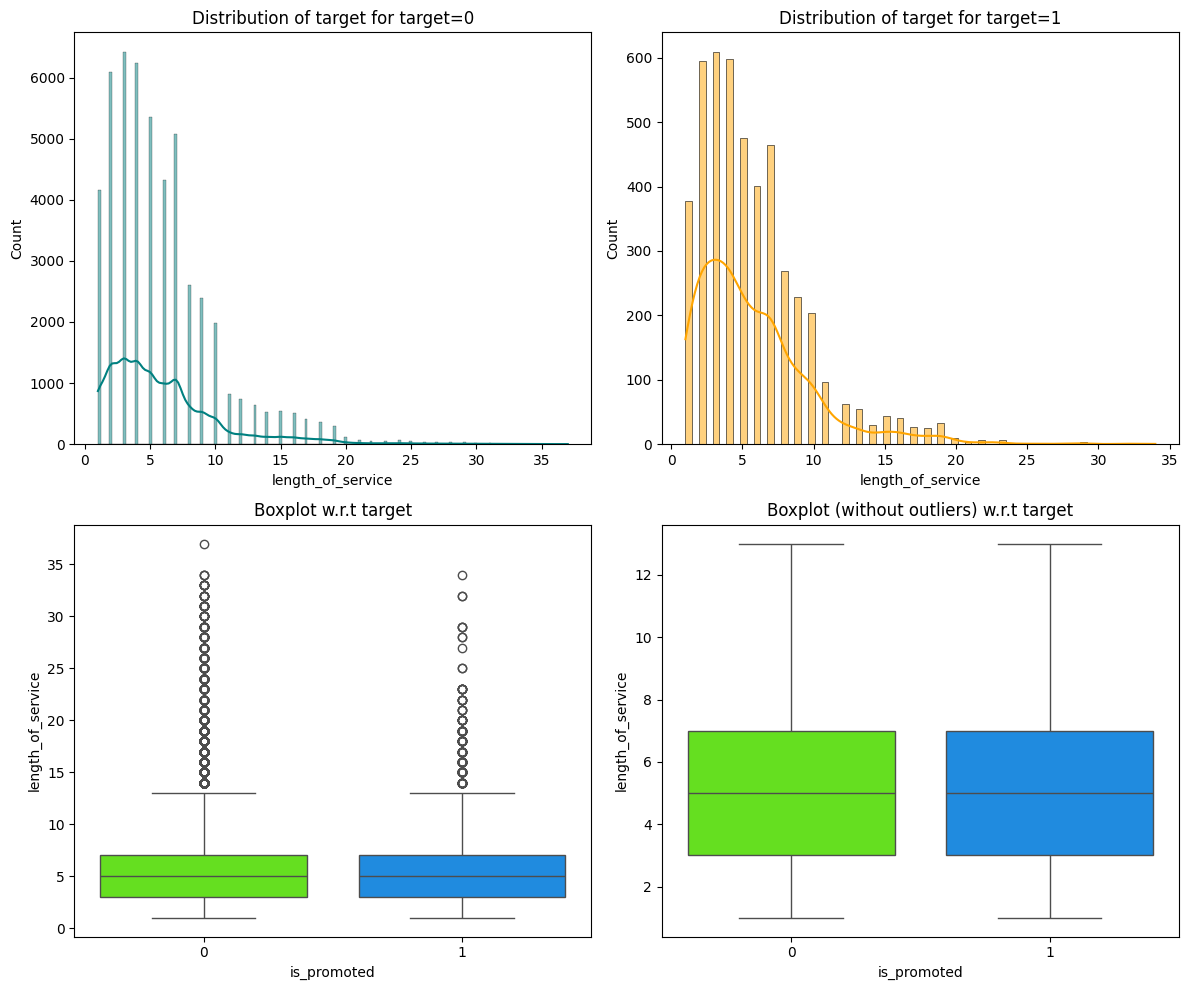

In [45]:
distribution_plot_wrt_target(data,'length_of_service','is_promoted')

Both promoted snd non-promted employees have a right-skewed distribution of length of service,with most employees having low to moderate tenure.However,promoted employees tend to have slightly higher tenure compared to non-promoted employees.

####Awards won vs Target

is_promoted      0     1    All
awards_won                     
All          50140  4668  54808
0            49429  4109  53538
1              711   559   1270
------------------------------------------------------------------------------------------------------------------------


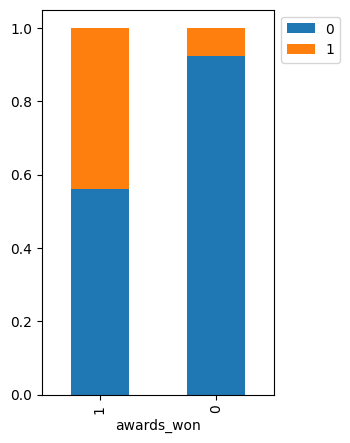

In [46]:
stacked_barplot(data,'awards_won','is_promoted')

Employees who have won awards have a significantly higher promotion rate compared to those who have not won any awards.

####Average Training Score vs Target

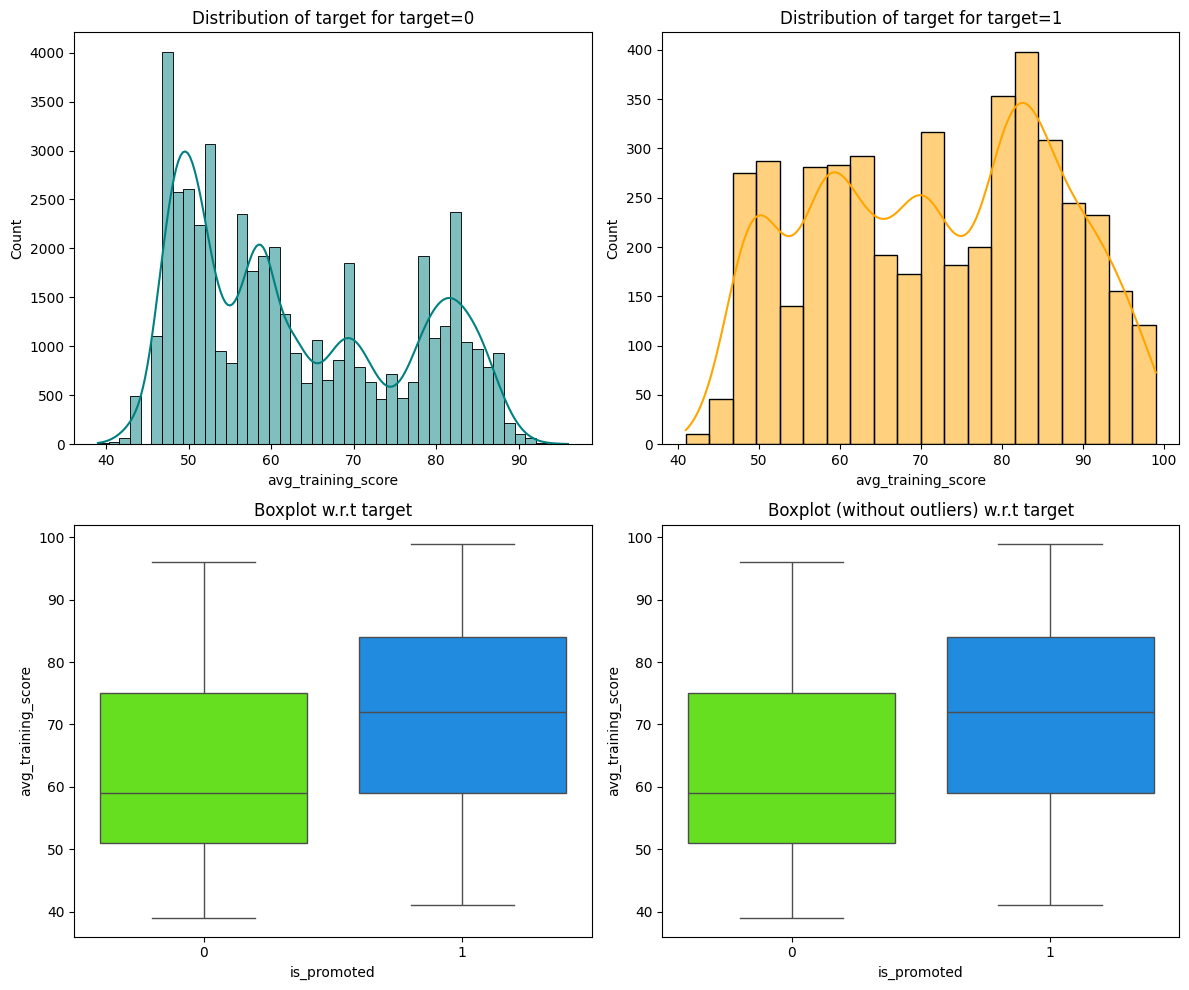

In [47]:
distribution_plot_wrt_target(data,'avg_training_score','is_promoted')

Eligible promotion employees tend to have higher average training score compared to non eligible employees for promotion.

####HeatMap

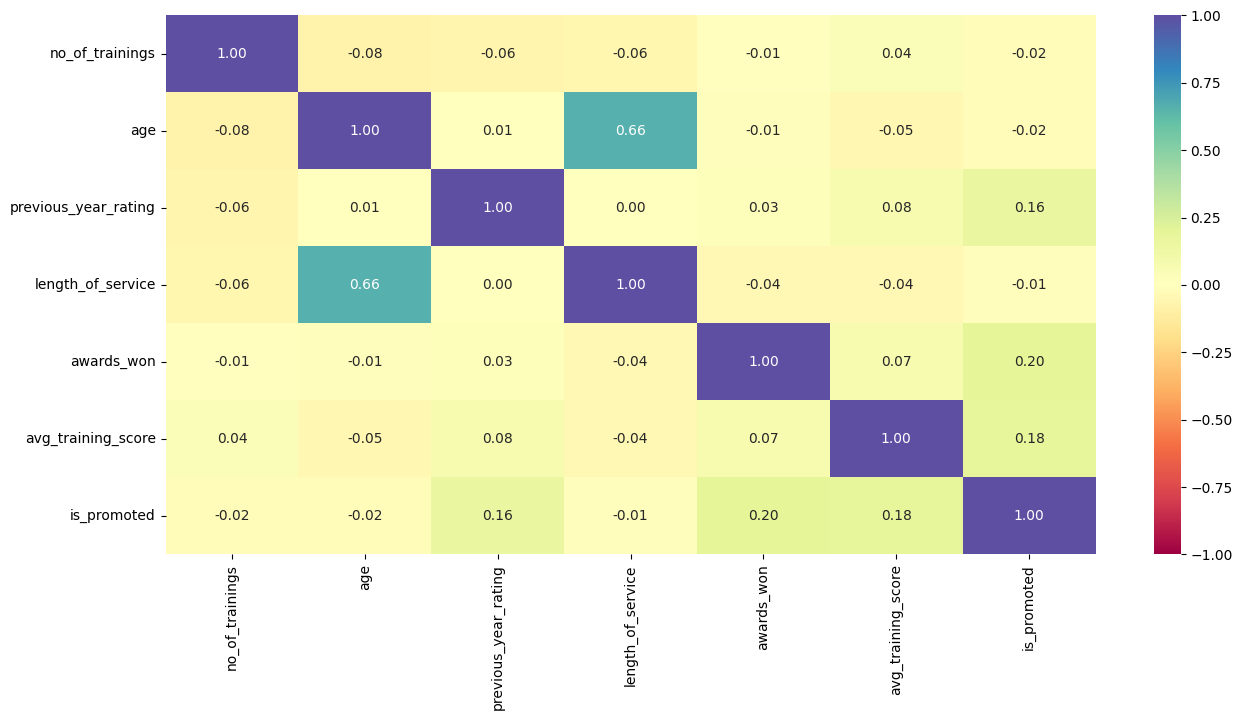

In [48]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

*   Previous year rating,average training score and awards won have a positive correlation.
*   Other variables have no significant correlation between them



## Data Pre-processing

In [49]:
df = data.copy()

In [52]:
X=df.drop('is_promoted',axis=1)
y=df['is_promoted']

In [53]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(32884, 11) (10962, 11) (10962, 11)


####Missing-Value Treatment


In [56]:
# Defining the imputers for numerical and categorical variables
imputer_mode = SimpleImputer(strategy="most_frequent")
imputer_median = SimpleImputer(strategy="median")

In [57]:
# Fit and transform the train data
X_train[["education"]] = imputer_mode.fit_transform(X_train[["education"]])

# Transform the validation data
X_val[["education"]]  =  imputer_mode.transform(X_val[["education"]])

# Transform the test data
X_test[["education"]] = imputer_mode.transform(X_test[["education"]])

In [58]:
# Fit and transform the train data
X_train[["previous_year_rating", "avg_training_score"]] = imputer_median.fit_transform(
    X_train[["previous_year_rating", "avg_training_score"]]
)
# Transform the validation data
X_val[["previous_year_rating", "avg_training_score"]] = imputer_median.transform(
    X_val[["previous_year_rating", "avg_training_score"]]
)
# Transform the test data
X_test[["previous_year_rating", "avg_training_score"]] = imputer_median.transform(
    X_test[["previous_year_rating", "avg_training_score"]]
)

In [59]:
# Checking that no column has missing values in train, validation and test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
dtype: int64
------------------------------
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
dtype: int64
------------------------------
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
dtype: int64


In [60]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

## Model Building

### Model evaluation criterion

**We will be using F1 score as a metric for our model performance because here both false positives and false negatives impact the business.**

1.   False Positive-Promoting undeserve employees.
2.   False Negative- Not promoting deserving employee


**How to reduce this loss i.e need to reduce False Negatives as well as False Positives?**

We need to focus on F1 Score as it balances both precision and Recall.ie F1 score should be maximized as both classes are important here

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [61]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred, average="macro")  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [62]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building with original data

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_val_score # Importing necessary functions
models = []  # Empty list to store all the models

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9239005736137668
Random forest: 0.9978601997146933
GBM: 0.4367436743674367
Adaboost: 0.2354391371340524
dtree: 0.9982174688057041

Validation Performance:

Bagging: 0.43210802700675166
Random forest: 0.37159372419488024
GBM: 0.4305669679539852
Adaboost: 0.2326007326007326
dtree: 0.3614336193841494


In [64]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9239, Validation Score: 0.4321, Difference: 0.4918
Random forest: Training Score: 0.9979, Validation Score: 0.3716, Difference: 0.6263
GBM: Training Score: 0.4367, Validation Score: 0.4306, Difference: 0.0062
Adaboost: Training Score: 0.2354, Validation Score: 0.2326, Difference: 0.0028
dtree: Training Score: 0.9982, Validation Score: 0.3614, Difference: 0.6368


Gradient boosting performs the best as it achieves high validation F1 score while maintaining minimal difference between training and validation scores,indicating better generalization without overfitting.Bagging also performs well but shows higher overfitting

### Model Building with Oversampled data


In [65]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 2800
Before Oversampling, counts of label 'No': 30084 

After Oversampling, counts of label 'Yes': 30084
After Oversampling, counts of label 'No': 30084 

After Oversampling, the shape of train_X: (60168, 52)
After Oversampling, the shape of train_y: (60168,) 



In [66]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9951797181219247
Random forest: 0.9997673336435552
GBM: 0.8863807890222984
Adaboost: 0.8173850770699768
dtree: 0.9997839203497166

Validation Performance:

Bagging: 0.3748395378690629
Random forest: 0.36324479540559945
GBM: 0.37272302662307333
Adaboost: 0.303363074811256
dtree: 0.32027092404450896


In [67]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9952, Validation Score: 0.3748, Difference: 0.6203
Random forest: Training Score: 0.9998, Validation Score: 0.3632, Difference: 0.6365
GBM: Training Score: 0.8864, Validation Score: 0.3727, Difference: 0.5137
Adaboost: Training Score: 0.8174, Validation Score: 0.3034, Difference: 0.5140
dtree: Training Score: 0.9998, Validation Score: 0.3203, Difference: 0.6795


Gradient Boosting is preferred as it achieves one of the highest validation F1 scores while maintaing a relatively lower gap between training and validation performance compared to other models.

### Model Building with Undersampled data

In [68]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [69]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 2800
Before Under Sampling, counts of label 'No': 30084 

After Under Sampling, counts of label 'Yes': 2800
After Under Sampling, counts of label 'No': 2800 

After Under Sampling, the shape of train_X: (5600, 52)
After Under Sampling, the shape of train_y: (5600,) 



In [70]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9784693323683734
Random forest: 0.9998214604534904
GBM: 0.7158978420114829
Adaboost: 0.6717330249463076
dtree: 0.9998213966779782

Validation Performance:

Bagging: 0.28972200969140527
Random forest: 0.3078055964653903
GBM: 0.3572755417956656
Adaboost: 0.23877515912609668
dtree: 0.23295344794282402


In [71]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9785, Validation Score: 0.2897, Difference: 0.6887
Random forest: Training Score: 0.9998, Validation Score: 0.3078, Difference: 0.6920
GBM: Training Score: 0.7159, Validation Score: 0.3573, Difference: 0.3586
Adaboost: Training Score: 0.6717, Validation Score: 0.2388, Difference: 0.4330
dtree: Training Score: 0.9998, Validation Score: 0.2330, Difference: 0.7669


Gradient Boosting performs best on undersampled data as it achieves the highest validation F1 score while also mainitaing the lowest difference between training and validation scores.

*   Gradient Boosting consistently performs well across original,oversampled, and undersampled datasets.It achieves a strong balance between validation F1 score and generalization,as indicated by a smaller gap between training and validation peformance
*   Other models achieve higher training scores, they exhibit significant overfitting.Oversampling improves minority class representation but slightly increases overfitting.Undersampling reduces overfitting but does not significantly improve validation performance.
 Therefore,Gradient Boosting is selected as the final model due to its stable perormance and better generalization.






### HyperparameterTuning

#### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
     "n_estimators": np.arange(10, 110, 10),
     "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
     "base_estimator": [
         DecisionTreeClassifier(max_depth=1, random_state=1),
         DecisionTreeClassifier(max_depth=2, random_state=1),
         DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,5,10],
   'learning_rate':[0.01,0.1,0.2,0.05],
   'gamma':[0,1,3,5],
   'subsample':[0.7,0.8,0.9,1]
}
```

#### Tuning Gradient Boosting with Original Data

In [74]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 0.2} with CV score=0.46444922446112136:


In [75]:
# Creating new pipeline with best parameters
tuned_gbm_original = GradientBoostingClassifier(
    max_features=0.7,
    random_state=1,
    learning_rate=0.2,
    n_estimators=125,
    subsample=0.5,
)
tuned_gbm_original.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.2, max_features=0.7,
                           n_estimators=125, random_state=1, subsample=0.5)

In [76]:
#Checking model's performance on training set
gbm_original_train = model_performance_classification_sklearn(
    tuned_gbm_original, X_train, y_train
)
gbm_original_train

,Accuracy,Recall,Precision,F1
0,0.941613,0.3325,0.948065,0.730679


In [78]:
# Checking model's performance on validation set
gbm_original_val = model_performance_classification_sklearn(tuned_gbm_original, X_val, y_val)
gbm_original_val

,Accuracy,Recall,Precision,F1
0,0.939427,0.32227,0.906627,0.721685


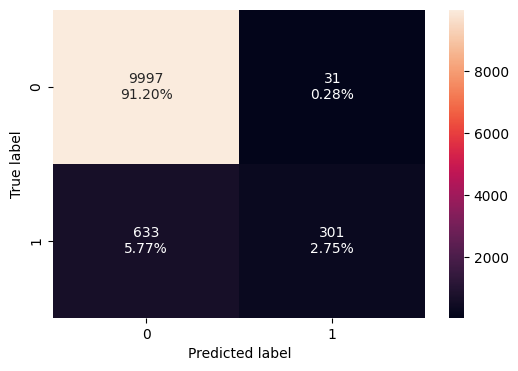

In [133]:
# creating confusion matrix
confusion_matrix_sklearn(tuned_gbm_original, X_val, y_val)

This confusion matrix shows that the model performs very well in identifying employees who should not be promoted,with a very few false positives.However,it struggles to identify employees eligible for promotion,as seen by the high number of false negatives.That means many deserving employees are not being recommended for promotion.

#### Tuning Gradient Boosting with Oversampled data:

In [80]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))


Best parameters are {'subsample': 1, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 1} with CV score=0.9338568334045126:


In [85]:
# Creating new pipeline with best parameters
tuned_gbm_oversampled = GradientBoostingClassifier(
    max_features=0.7,
    random_state=1,
    learning_rate=1,
    n_estimators=125,
    subsample=1,
)
tuned_gbm_oversampled.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=1, max_features=0.7, n_estimators=125,
                           random_state=1, subsample=1)

In [86]:
#Checking model's performance on training set
gbm_oversampled_train = model_performance_classification_sklearn(
    tuned_gbm_oversampled, X_train_over, y_train_over
)
gbm_oversampled_train

,Accuracy,Recall,Precision,F1
0,0.955491,0.927403,0.982602,0.955456


In [88]:
# Checking model's performance on validation set
gbm_oversampled_val = model_performance_classification_sklearn(tuned_gbm_oversampled, X_val, y_val)
gbm_oversampled_val

,Accuracy,Recall,Precision,F1
0,0.924649,0.346895,0.6,0.699614


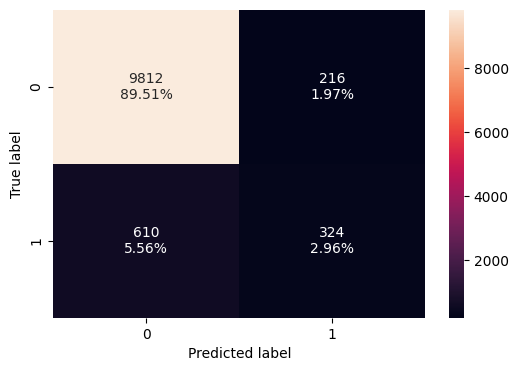

In [89]:
# creating confusion matrix
confusion_matrix_sklearn(tuned_gbm_oversampled, X_val, y_val)

The GBM model trained on oversampled data improves recall and reduces false negatives.

#### Tuning Gradient Boosting with Undersampled data:

In [90]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 0.1} with CV score=0.6952973360622574:


In [91]:
# Creating new pipeline with best parameters
tuned_gbm_undersampled = GradientBoostingClassifier(
    max_features=0.7,
    random_state=1,
    learning_rate=0.1,
    n_estimators=125,
    subsample=0.7,
)
tuned_gbm_undersampled.fit(X_train_un, y_train_un)

GradientBoostingClassifier(max_features=0.7, n_estimators=125, random_state=1,
                           subsample=0.7)

In [92]:
#Checking model's performance on training set
gbm_undersampled_train = model_performance_classification_sklearn(
    tuned_gbm_undersampled, X_train_un, y_train_un
)
gbm_undersampled_train

,Accuracy,Recall,Precision,F1
0,0.751607,0.683214,0.791477,0.75044


In [93]:
# Checking model's performance on validation set
gbm_undersampled_val = model_performance_classification_sklearn(tuned_gbm_undersampled, X_val, y_val)
gbm_undersampled_val

,Accuracy,Recall,Precision,F1
0,0.786444,0.664882,0.234428,0.6095


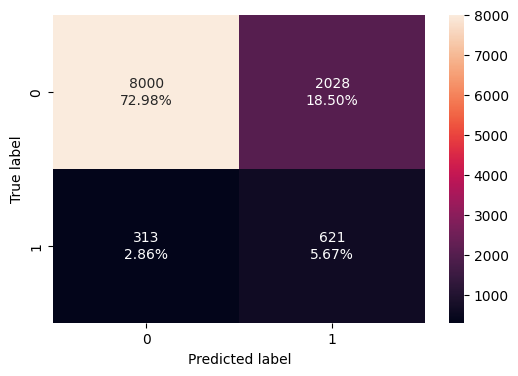

In [94]:
# creating confusion matrix
confusion_matrix_sklearn(tuned_gbm_undersampled, X_val, y_val)

The undersampled Gradient Boosting model improves recall by identifying more employees eligible for promotion.However it significantly increases false positives,resulting in many incorrect promotion recommendation.This reduces precision and overall F1 score.

## Model Comparison and Final Model Selection

In [95]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_original_train.T,
        gbm_oversampled_train.T,
        gbm_undersampled_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "Gradient boosting trained with Undersampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data,Gradient boosting trained with Undersampled data
Accuracy,0.941613,0.955491,0.751607
Recall,0.332500,0.927403,0.683214
Precision,0.948065,0.982602,0.791477
F1,0.730679,0.955456,0.750440


In [96]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm_original_val.T, gbm_oversampled_val.T, gbm_undersampled_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "Gradient boosting trained with Undersampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data,Gradient boosting trained with Undersampled data
Accuracy,0.939427,0.924649,0.786444
Recall,0.322270,0.346895,0.664882
Precision,0.906627,0.600000,0.234428
F1,0.721685,0.699614,0.609500


Tuned Gradient Boosting on original data is the best because it gives the highest F1 score with strong precision and stable generalization.

### Test set final performance

In [97]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(tuned_gbm_original, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.940339,0.330835,0.914201,0.727091


The final model selected is the tuned Gradient Boosting model trained on the original dataset.The model achieves an F1 score of 0.727 on the test set,with high precision(0.914) and stable recall(0.331).The test performance closely matches the validation performance,indicating that the model generalizes well and does not suffer from overfitting

####Feature Importance

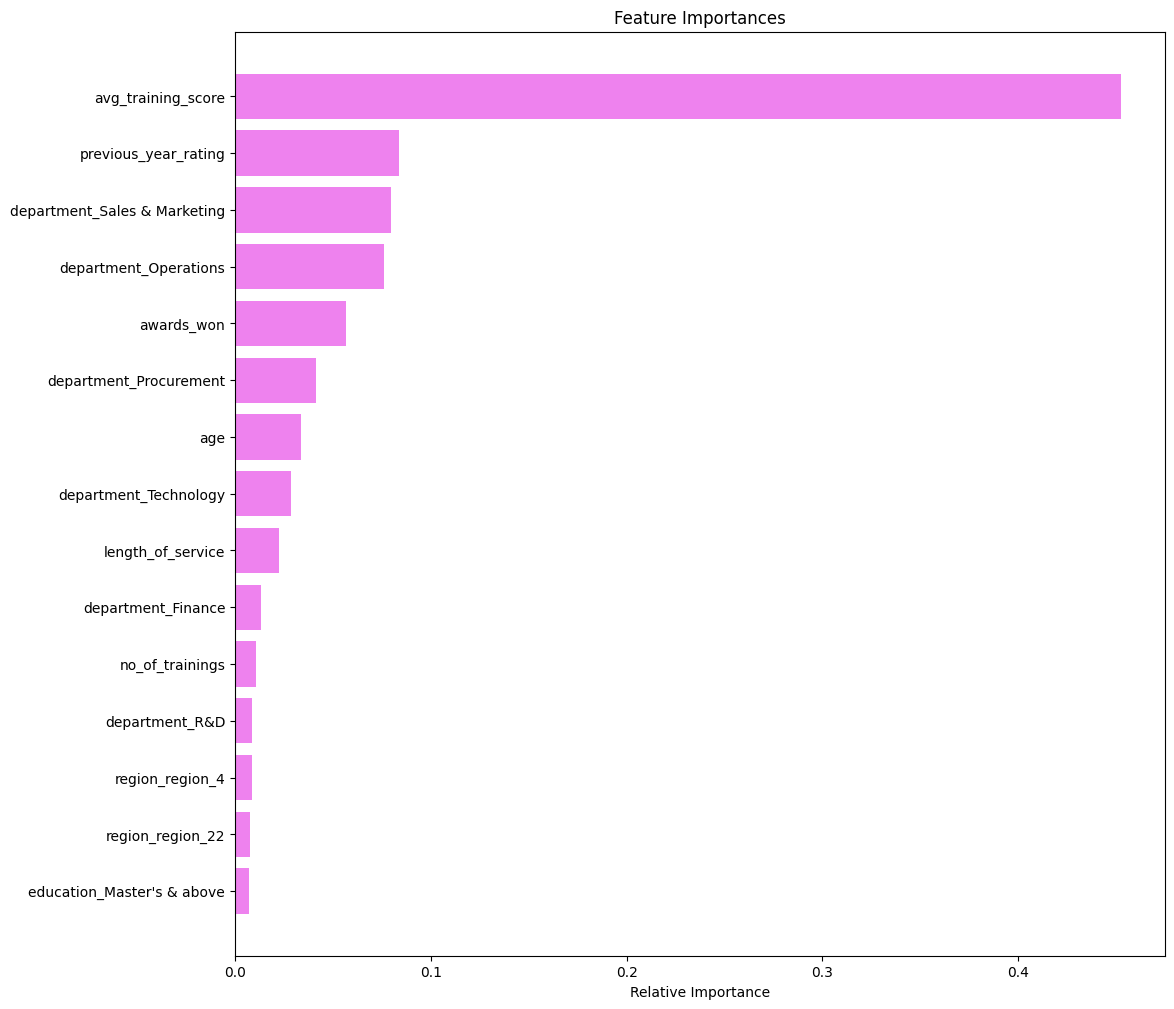

In [100]:
feature_names = X_train.columns
importances = tuned_gbm_original.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Feature importance analysis shows that the average training score is the most influential factor in predicting employee promotion.Previous year rating,department  and awards won also play significant roles.

# Business Insights and Conclusions



*   The analysis reveals that the employee promotion decisions are strongly influenced by performance related factors and awards won,particularly the average training score and previous year rating.Employees with higher training scores and previous year rating are significantly more likely to be recommended for promotion.
*   Promotion rates vary across  different business units.This suggests that certain departments have more opportunities.
* Factors such as age and length of service have relatively lower impact,indicating that promotions are more performance based.
*   The final Gradient Boosting model demonstrates strong performance with high precision,ensuring the most recommended employees are truely deserving.
*   The model also shows stable performance on unseen test data,confirming good generalization.








***